# Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
import joblib
import pickle
import warnings
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, RocCurveDisplay)

# Load dataset📅

In [9]:

df = pd.read_csv("/kaggle/input/bank-customer-churn-prediction/Churn_Modelling.csv")

# Initial data exploration

In [5]:

print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# Exploratory Data Analysis (EDA)
## - Target variable distribution
## - Numerical features distribution
## - Categorical features distribution

In [6]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
plt.figure(figsize=(20, 26))

plt.subplot(4, 2, 1)
sns.countplot(x='Exited', data=df)
plt.title('Target Variable Distribution')


numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
for i, feature in enumerate(numerical_features, 2):
    plt.subplot(4, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'{feature} Distribution')
    
plt.subplot(4, 2, 8)
sns.countplot(x='Geography', data=df)
plt.title('Geography Distribution')

# Correlation analysis

In [ ]:

plt.figure(figsize=(12, 8))
corr_matrix = df.drop(['RowNumber', 'CustomerId', 'Surname','Gender','Geography'], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing
## - Remove irrelevant columns
## - Encode categorical variables

In [10]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df = pd.get_dummies(df, columns=['Geography', 'Gender'])
df = df.replace({True: 1, False: 0})

<ipython-input-10-990138d060b5>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [11]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,1,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1,0,0,1


# Get sample form the Clean Data

In [ ]:
df_sample = df.sample(frac=0.2, random_state=42) 
df_sample.to_csv('/kaggle/working/sample_data.csv', index=False)

# Split data into features and target

In [13]:

X = df.drop('Exited', axis=1)
y = df['Exited']# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [14]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,1,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,1,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,0,1,0,0,1


In [15]:
x_sample = df.sample(frac=0.01, random_state=42) 
x_sample.to_csv('/kaggle/working/x_sample.csv', index=False)

# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42 )

In [ ]:
sample =X_train.sample(frac=0.2, random_state=42) 
sample.to_csv('/kaggle/working/sample.csv', index=False)

# Feature scaling

In [16]:

scaler = StandardScaler()
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [17]:
joblib.dump(scaler, 'scaler1.pkl')
print("Model saved as scaler1.pkl")

Model saved as scaler1.pkl


# Handle class **imbalance** using **SMOTE** 📉

In [18]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [19]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    # 'SVM': SVC(probability=True),
    'xgb': xgb.XGBClassifier(max_depth= 20,eta=0.3, n_estimators=100,subsample=1 )
}

# Evaluate base models

In [20]:

results = {}
for name, clf in classifiers.items():
    cv = StratifiedKFold(n_splits=5)
    scores = cross_val_score(clf, X_train_smote, y_train_smote, 
                            cv=cv, scoring='roc_auc')
    results[name] = scores.mean()
    print(f"{name}: Average ROC-AUC = {scores.mean():.4f}")

Logistic Regression: Average ROC-AUC = 0.8200
Random Forest: Average ROC-AUC = 0.9637
Gradient Boosting: Average ROC-AUC = 0.9303
xgb: Average ROC-AUC = 0.9660


# The Best Model selection👌

In [21]:
best_model_name = max(results, key=results.get)
print(f"\nBest model: {best_model_name}")
best_model=classifiers[best_model_name]


Best model: xgb


# Evaluatin for All Alogrithms 
### - Cross_validation Prediction
### - Evaulation Martices

In [22]:
evaluation_results = {}
for name, clf in classifiers.items():
    # Cross-validation predictions
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(clf, X_train_smote, y_train_smote, cv=cv, method="predict")
    y_pred_proba = cross_val_predict(clf, X_train_smote, y_train_smote, cv=cv, method="predict_proba")[:, 1]

    # Compute evaluation metrics
    accuracy = accuracy_score(y_train_smote, y_pred)
    precision = precision_score(y_train_smote, y_pred)
    recall = recall_score(y_train_smote, y_pred)
    f1 = f1_score(y_train_smote, y_pred)
    roc_auc = roc_auc_score(y_train_smote, y_pred_proba)

    # Store results
    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }
    
# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(evaluation_results).T
print("\nEvaluation Results Summary:")
results_df


Evaluation Results Summary:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.742779,0.750040,0.728257,0.738988,0.821207
Random Forest,0.900392,0.898453,0.902826,0.900634,0.962103
Gradient Boosting,0.863422,0.874474,0.848666,0.861377,0.934812
xgb,0.905416,0.904084,0.907064,0.905572,0.965661


<Figure size 1000x600 with 0 Axes>

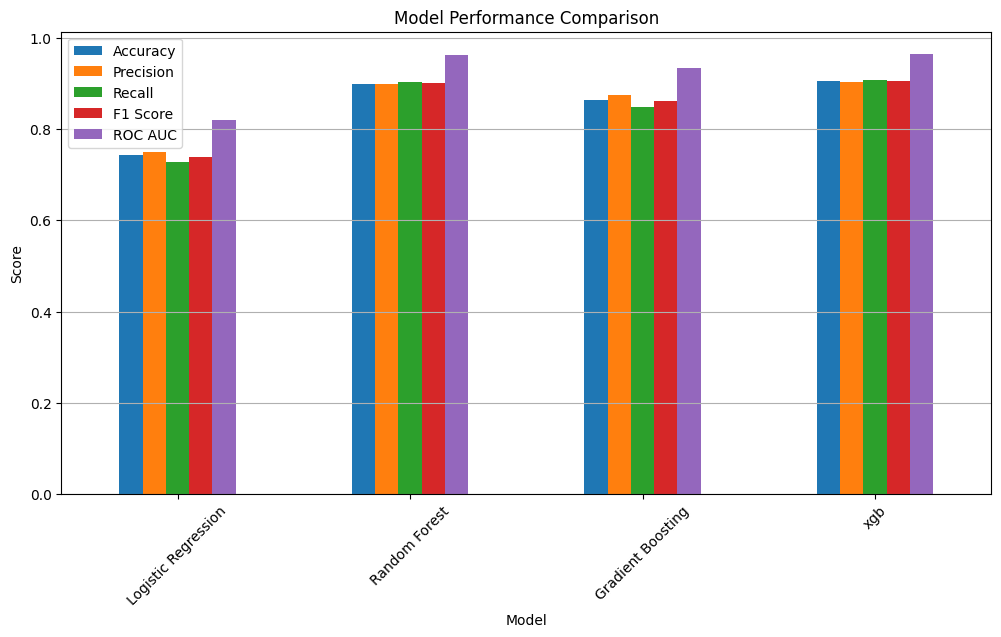

In [23]:
# Optional: Plot results
plt.figure(figsize=(10, 6))
results_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="best")
plt.grid(axis="y")
plt.show()

# Final model evaluation of the Best model📸
## - Confusion Matrix
## - ROC Curve📈


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1593
           1       0.60      0.53      0.56       407

    accuracy                           0.83      2000
   macro avg       0.74      0.72      0.73      2000
weighted avg       0.82      0.83      0.83      2000

ROC-AUC Score: 0.8278


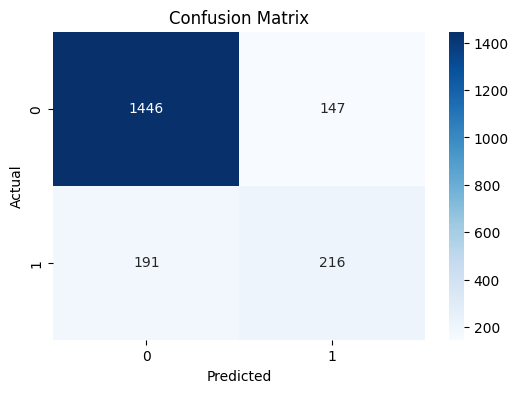

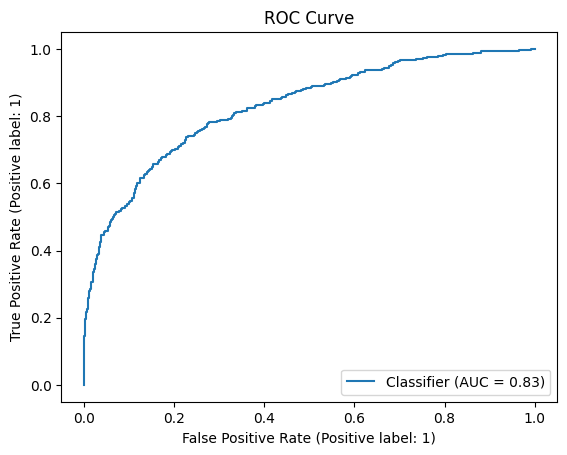

In [25]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb

# Define the model
model = xgb.XGBClassifier(
    max_depth=20, 
    eta=0.3, 
    n_estimators=100, 
)

# Define Stratified K-Fold (to maintain class balance in folds)
model.fit(X_train_smote, y_train_smote)  # تأكد من تدريب النموذج قبل التنبؤ
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute and print ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve')
plt.show()

# Save the final model🎯

In [26]:

joblib.dump(model, 'model2.pkl')
print("Model saved as model2.pkl")

Model saved as model2.pkl


# Feature importance using XGBoost 
### - Get feature importances
### - Plot bar chart📊

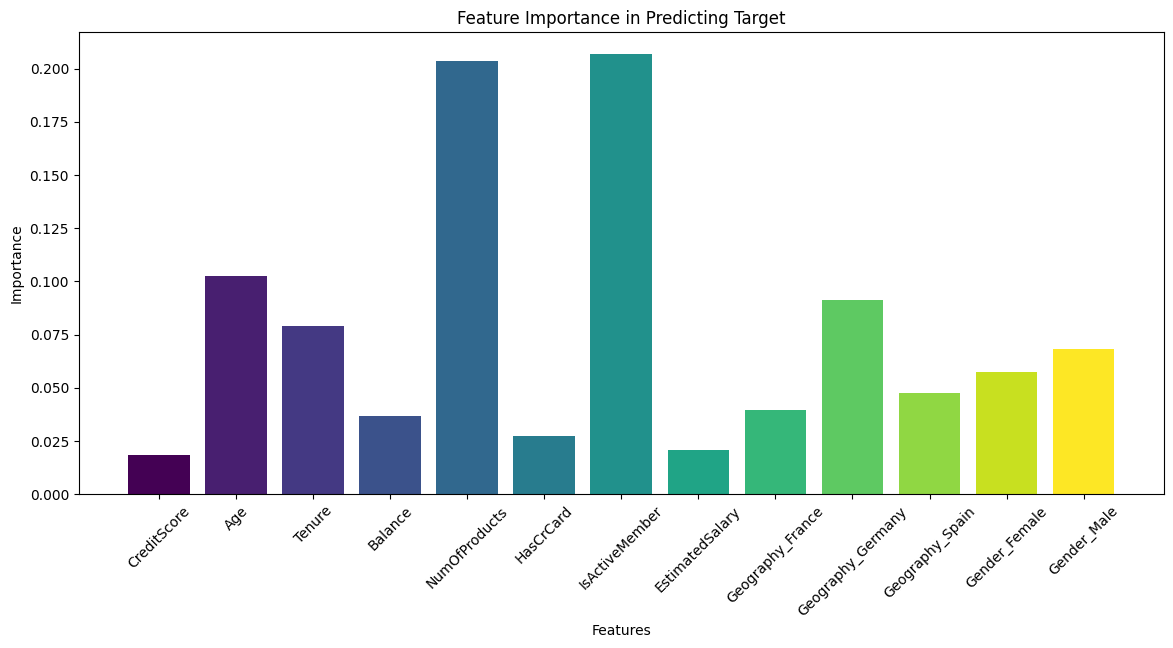

In [27]:
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train_smote, y_train_smote)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns 

# Ensure numpy is imported
plt.figure(figsize=(14, 6))

# Generate colors dynamically based on feature count
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))

# Plot the feature importances
plt.bar(feature_names, importances, color=colors)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Predicting Target")
plt.xticks(rotation=45)
plt.show()